# AE 696 — Lab 2: Value Iteration for Stochastic Robot Navigation

This lab follows the gridworld, notation, and Bellman optimality update used in Lectures 7–10. You will implement a stochastic transition model, value iteration, greedy policy extraction, convergence visualization, and a seeded policy rollout.

**Submission:** one completed `.ipynb` file. Before submitting, select **Restart Kernel and Run All**. Every public check must print `passed`.

## Objective grading (100 points)

| Item | Required output | Points |
|---|---|---:|
| Notebook identification and run-all | Name/Red ID entered; all cells execute in order | 5 |
| Task 1: transition model | `transition_outcomes` passes the stated checks | 20 |
| Task 2: Bellman backup | `action_value` and `bellman_optimality_backup` pass the stated checks | 15 |
| Task 3: value iteration | `V_star`, `policy_star`, and `deltas` pass the stated checks | 30 |
| Task 4: plots | Both required figure objects are produced without error | 10 |
| Task 5: seeded rollout | Required trajectory and return match the stated seed | 10 |
| Task 6: discount-factor experiment | `gamma_results` matches all stated values | 10 |

Every graded item has a fixed, executable result. Grading is based on named variables, function outputs, and assertions only.

In [3]:
# Enter your information.
STUDENT_NAME = "Wyatt Welch"
RED_ID = "828496091"

print(f"Student: {STUDENT_NAME or '[not entered]'}")
print(f"Red ID:  {RED_ID or '[not entered]'}")

Student: Wyatt Welch
Red ID:  828496091


## Environment specification

The lecture grid uses 1-based coordinates. This notebook uses standard Python 0-based coordinates, so lecture cell $(1,1)$ is Python state `(0, 0)`.

- Grid: 4 rows × 5 columns
- Start: lecture $(1,1)$ → Python `(0, 0)`
- Goal: lecture $(4,5)$ → Python `(3, 4)`
- Obstacles: lecture $(1,3),(2,3),(3,2),(3,4)$
- Actions: up, down, left, right
- Motion: intended direction with probability 0.8; each perpendicular slip with probability 0.1
- Boundary or obstacle collision: remain in the current state
- Reward: +10 for entering the goal, −20 for a collision, and −1 otherwise
- Discount factor: $\gamma=0.95$
- The goal is terminal; no future reward is added after entry.

In [4]:
from collections import defaultdict
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.patches import Rectangle

# SDSU visual palette used in the course materials.
SDSU_RED = "#A6192E"
SDSU_GOLD = "#C69214"
SDSU_BLACK = "#000000"
SDSU_GRAY = "#A7A8AA"

ROWS, COLS = 4, 5
START = (0, 0)
GOAL = (3, 4)
OBSTACLES = {(0, 2), (1, 2), (2, 1), (2, 3)}


ACTIONS = ("U", "D", "L", "R")

DELTAS = {"U": (-1, 0), 
          "D": (1, 0), 
          "L": (0, -1), 
          "R": (0, 1)
}

PERPENDICULAR = {
    "U": ("L", "R"),
    "D": ("R", "L"),
    "L": ("D", "U"),
    "R": ("U", "D"),
}

ARROWS = {"U": "↑", 
          "D": "↓", 
          "L": "←", 
          "R": "→", 
          "G": "G"
}

P_INTENDED = 0.8
P_SLIP = 0.1
STEP_REWARD = -1.0
COLLISION_REWARD = -20.0
GOAL_REWARD = 10.0
GAMMA = 0.95
THETA = 1e-8

VALID_STATES = tuple(
    (row, col)
    for row in range(ROWS)
    for col in range(COLS)
    if (row, col) not in OBSTACLES
)

def is_valid_state(state): # Returns True/False
    row, col = state
    return 0 <= row < ROWS and 0 <= col < COLS and state not in OBSTACLES

print(f"Valid states (including terminal goal): {len(VALID_STATES)}")

Valid states (including terminal goal): 16


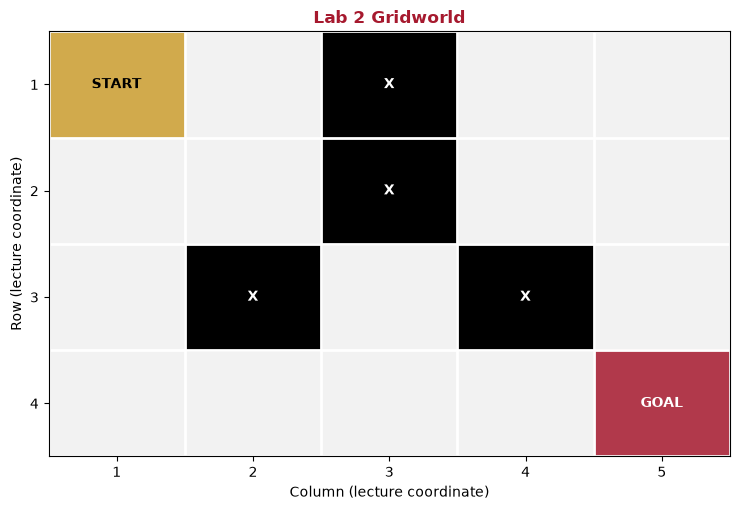

In [5]:
def plot_environment():
    fig, ax = plt.subplots(figsize=(7.5, 5.2))
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_xticks(range(COLS), labels=range(1, COLS + 1))
    ax.set_yticks(range(ROWS), labels=range(1, ROWS + 1))
    ax.set_xlabel("Column (lecture coordinate)")
    ax.set_ylabel("Row (lecture coordinate)")
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_facecolor("#F2F2F2")

    for row, col in OBSTACLES:
        ax.add_patch(Rectangle((col - 0.5, row - 0.5), 1, 1, color=SDSU_BLACK))
        ax.text(col, row, "X", color="white", ha="center", va="center", weight="bold")

    ax.add_patch(Rectangle((START[1] - 0.5, START[0] - 0.5), 1, 1, color=SDSU_GOLD, alpha=0.75))
    ax.text(START[1], START[0], "START", ha="center", va="center", weight="bold")
    ax.add_patch(Rectangle((GOAL[1] - 0.5, GOAL[0] - 0.5), 1, 1, color=SDSU_RED, alpha=0.85))
    ax.text(GOAL[1], GOAL[0], "GOAL", color="white", ha="center", va="center", weight="bold")
    ax.set_title("Lab 2 Gridworld", color=SDSU_RED, weight="bold")
    plt.tight_layout()
    return fig

environment_figure = plot_environment()
plt.show()

## Task 1 — Stochastic transition model (20 points)

Complete `transition_outcomes(state, action)`. It must return a list of tuples

```python
(probability, next_state, reward, done)
```

Aggregate identical outcomes. For example, two collision branches that produce the same next state, reward, and terminal flag must appear as one tuple with the summed probability. Preserve the intended/slip branch order when adding outcomes.

In [6]:
"""
#    0  1  2  3  4
# 0 [S][ ][X][ ][ ]
# 1 [ ][ ][X][ ][ ]
# 2 [ ][X][ ][X][ ]
# 3 [ ][ ][ ][ ][G]

"""

def transition_outcomes(state, action):
    """Return aggregated stochastic outcomes for one state-action pair."""
    if state not in VALID_STATES:
        raise ValueError(f"Invalid state: {state}")
    if action not in ACTIONS:
        raise ValueError(f"Invalid action: {action}")
    if state == GOAL:
        return [(1.0, GOAL, 0.0, True)]

    # TODO 1: implement the 0.8/0.1/0.1 motion model.
    # Hint: use defaultdict(float) and aggregate by (next_state, reward, done).

    outcomes = defaultdict(float)

    slip_1, slip_2 = PERPENDICULAR[action]

    possible_directions = [
        (action, P_INTENDED),
        (slip_1, P_SLIP),
        (slip_2, P_SLIP)
    ]


    for outcome in possible_directions:
        direction = outcome[0]
        probability = outcome[1]

        delta_row, delta_col = DELTAS[direction]

        attempted_state = (
            state[0] + delta_row,
            state[1] + delta_col
        )

        if is_valid_state(attempted_state): 
            next_state = attempted_state
            if next_state == GOAL:
                reward = GOAL_REWARD
            else:
                reward = STEP_REWARD
        else:
            next_state = state
            reward = COLLISION_REWARD

        done = next_state == GOAL
        key = (next_state, reward, done)
        outcomes[key] += probability

    return [
        (probability, next_state, reward, done)
        for (next_state, reward, done), probability in outcomes.items() 
    ] # first three are a touple, last live changes?

"""
state = (1,1)
action = "D"
outcomes = transition_outcomes(state, action)
print(outcomes)
    # [(0.9, (1, 1), -20.0, False), (0.1, (1, 0), -1.0, False)]
"""

'\nstate = (1,1)\naction = "D"\noutcomes = transition_outcomes(state, action)\nprint(outcomes)\n    # [(0.9, (1, 1), -20.0, False), (0.1, (1, 0), -1.0, False)]\n'

In [7]:
# Public checks for Task 1. Do not edit this cell.
def outcomes_as_dict(outcomes):
    return {(next_state, reward, done): probability for probability, next_state, reward, done in outcomes}

for state in VALID_STATES:
    for action in ACTIONS:
        outcomes = transition_outcomes(state, action)
        assert math.isclose(sum(item[0] for item in outcomes), 1.0, abs_tol=1e-12)
        assert all(item[0] > 0.0 for item in outcomes)

near_goal = outcomes_as_dict(transition_outcomes((3, 3), "R"))
assert near_goal == {((3, 4), 10.0, True): 0.8, ((3, 3), -20.0, False): 0.2}

top_left = outcomes_as_dict(transition_outcomes((0, 0), "U"))
assert top_left == {((0, 0), -20.0, False): 0.9, ((0, 1), -1.0, False): 0.1}

assert transition_outcomes(GOAL, "U") == [(1.0, GOAL, 0.0, True)]
print("Task 1 public checks passed.")

Task 1 public checks passed.


## Task 2 — Bellman optimality backup (15 points)

Implement

$$Q(s,a)=\sum_{s',r}p(s',r\mid s,a)\left[r+\gamma(1-\texttt{done})V(s')\right]$$

and return the maximum action value together with its greedy action. Break ties by the fixed order `U, D, L, R`.

In [ ]:
def action_value(state, action, V, gamma=GAMMA):
    """Compute Q(s, a) from the supplied value dictionary."""
    # TODO 2a

    # Call from transition table
    outcomes = transition_outcomes(state, action)
    # returns (next_state, reward, done), probability

    # probability of next state and reward given current state and action
    value = 0
    for probability, next_state, reward, done in outcomes:
        value += probability * (reward + gamma * (1 - done) * V[next_state])
    return value
    


def bellman_optimality_backup(state, V, gamma=GAMMA):
    """Return (max_a Q(s,a), greedy_action) using ACTIONS tie order."""
    if state == GOAL:
        return 0.0, "G"

    greedy = ACTIONS[0]
    max_Q = action_value(state, greedy, V, gamma=gamma)

    for action in ACTIONS:
        Q = action_value(state, action, V, gamma=gamma)
        if Q > max_Q + 1e-12:
            max_Q = Q
            greedy = action

    return max_Q, greedy


In [9]:
# Public checks for Task 2. Do not edit this cell.
V_zero = {state: 0.0 for state in VALID_STATES}

assert math.isclose(action_value((3, 3), "R", V_zero), 4.0, abs_tol=1e-12)
assert math.isclose(action_value((0, 0), "U", V_zero), -18.1, abs_tol=1e-12)

backup_value, backup_action = bellman_optimality_backup((3, 3), V_zero)
assert math.isclose(backup_value, 4.0, abs_tol=1e-12)
assert backup_action == "R"
assert bellman_optimality_backup(GOAL, V_zero) == (0.0, "G")
print("Task 2 public checks passed.")

Task 2 public checks passed.


## Task 3 — Synchronous value iteration (30 points)

Complete `value_iteration`. Each sweep must use a copy of the previous value function (synchronous updates). Stop after appending the first sweep whose maximum change is strictly below `theta`. The returned policy must be greedy with respect to the converged values.

In [13]:
def value_iteration(theta=THETA, gamma=GAMMA, max_iterations=10_000):
    """Return (V, policy, deltas) using synchronous Bellman updates."""

    V = {state:0 for state in VALID_STATES}
    deltas = []

    while True:
        max_change = 0
        V_curr = V.copy()
        V_new = {}

        for state in VALID_STATES:
            new_value, action = bellman_optimality_backup(state, V_curr, gamma)
            V_new[state] = new_value

            dV = abs(new_value - V_curr[state])

            if dV > max_change:
                max_change = dV

        deltas.append(max_change)
        V = V_new

        if max_change < theta:
            break

    V_star = V # after converge
    policy_star = {}

    for state in VALID_STATES:
        value, action = bellman_optimality_backup(state, V_star, gamma)
        # action that produces highest value
        policy_star[state] = action

    return V_star, policy_star, deltas

V_star, policy_star, deltas = value_iteration()

In [ ]:
# Public checks for Task 3. Do not edit this cell.
EXPECTED_POLICY = {
    (0, 0): "D", (0, 1): "D",                 (0, 3): "D", (0, 4): "D",
    (1, 0): "D", (1, 1): "L",                 (1, 3): "R", (1, 4): "D",
    (2, 0): "D",                 (2, 2): "D",                 (2, 4): "D",
    (3, 0): "R", (3, 1): "R", (3, 2): "R", (3, 3): "R", (3, 4): "G",
}

assert set(V_star) == set(VALID_STATES)
assert set(policy_star) == set(VALID_STATES)
assert policy_star == EXPECTED_POLICY
assert len(deltas) == 39
assert all(delta >= 0.0 for delta in deltas)
assert deltas[-1] < THETA
assert math.isclose(V_star[START], -20.508278595324025, abs_tol=1e-6)
assert math.isclose(V_star[(3, 3)], 4.938271604938271, abs_tol=1e-6)
assert V_star[GOAL] == 0.0
assert all(np.isfinite(value) for value in V_star.values())
print("Task 3 public checks passed.")
print(f"Converged in {len(deltas)} sweeps; V(start) = {V_star[START]:.6f}")

## Task 4 — Required plots (10 points)

Run the supplied plotting code. Grading checks that both required `Figure` objects are created and that the cells execute without error.

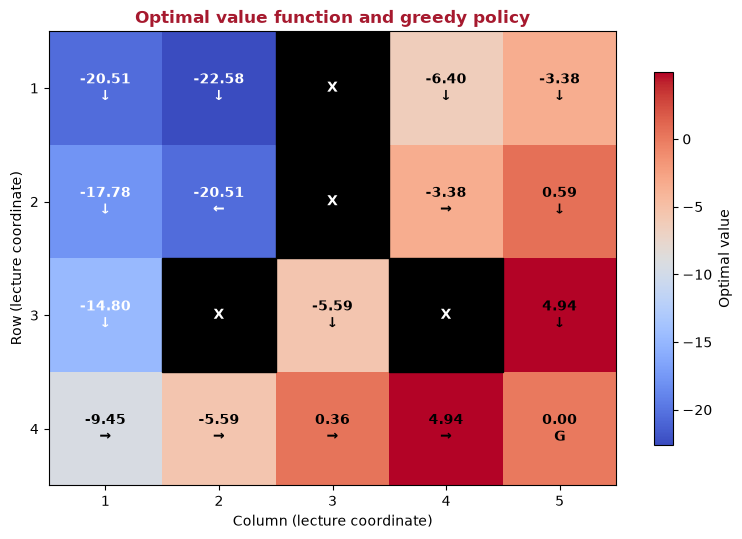

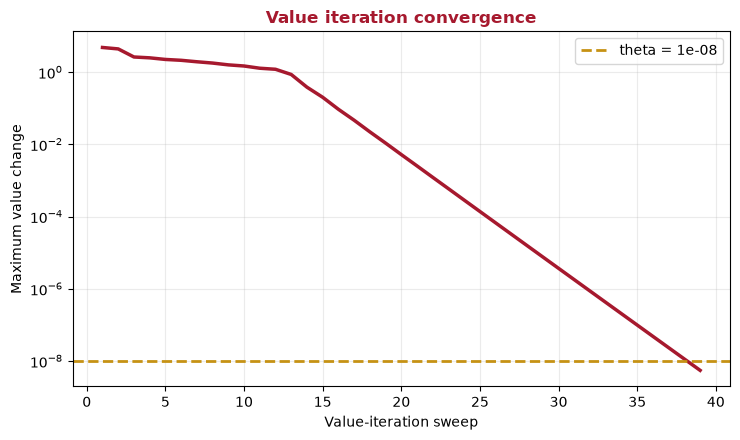

Task 4 public checks passed.


In [14]:
def plot_values_and_policy(V, policy):
    value_grid = np.full((ROWS, COLS), np.nan)
    for state, value in V.items():
        value_grid[state] = value

    fig, ax = plt.subplots(figsize=(8.2, 5.4))
    image = ax.imshow(value_grid, cmap="coolwarm", aspect="equal")
    fig.colorbar(image, ax=ax, shrink=0.82, label="Optimal value")

    for row in range(ROWS):
        for col in range(COLS):
            state = (row, col)
            if state in OBSTACLES:
                ax.add_patch(Rectangle((col - 0.5, row - 0.5), 1, 1, color=SDSU_BLACK))
                ax.text(col, row, "X", color="white", ha="center", va="center", weight="bold")
            else:
                arrow = ARROWS[policy[state]]
                label = f"{V[state]:.2f}\n{arrow}"
                color = "white" if abs(V[state]) > 10 else SDSU_BLACK
                ax.text(col, row, label, color=color, ha="center", va="center", weight="bold")

    ax.set_xticks(range(COLS), labels=range(1, COLS + 1))
    ax.set_yticks(range(ROWS), labels=range(1, ROWS + 1))
    ax.set_xlabel("Column (lecture coordinate)")
    ax.set_ylabel("Row (lecture coordinate)")
    ax.set_title("Optimal value function and greedy policy", color=SDSU_RED, weight="bold")
    plt.tight_layout()
    return fig


def plot_convergence(deltas):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.semilogy(range(1, len(deltas) + 1), deltas, color=SDSU_RED, linewidth=2.5)
    ax.axhline(THETA, color=SDSU_GOLD, linestyle="--", linewidth=2, label=f"theta = {THETA:g}")
    ax.set_xlabel("Value-iteration sweep")
    ax.set_ylabel("Maximum value change")
    ax.set_title("Value iteration convergence", color=SDSU_RED, weight="bold")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    return fig


value_policy_figure = plot_values_and_policy(V_star, policy_star)
plt.show()
convergence_figure = plot_convergence(deltas)
plt.show()

assert isinstance(value_policy_figure, Figure)
assert isinstance(convergence_figure, Figure)
assert len(value_policy_figure.axes) == 2  # main axis plus colorbar
assert len(convergence_figure.axes) == 1
print("Task 4 public checks passed.")

## Task 5 — Seeded policy rollout (10 points)

Complete `simulate_policy`. Use `np.random.default_rng(seed)` and one `rng.random()` draw per transition. Select the first outcome whose cumulative probability is greater than or equal to the draw. Stop immediately after reaching the goal.

In [19]:
def sample_transition(state, action, rng):
    draw = rng.random()
    cumulative_probability = 0.0
    for probability, next_state, reward, done in transition_outcomes(state, action):
        cumulative_probability += probability
        if draw <= cumulative_probability:
            return next_state, reward, done
    raise RuntimeError("Transition probabilities did not sum to one.")


def simulate_policy(policy, seed=7, max_steps=200):
    """Return (trajectory, rewards, reached_goal)."""
    state = START
    trajectory = [START]
    rollout_rewards = []
    reached_goal = False

    rng = np.random.default_rng(seed)
    for i in range(max_steps):
        action = policy[state]
        next_state, reward, done = sample_transition(state, action, rng)

        trajectory.append(next_state)
        rollout_rewards.append(reward)
        state = next_state

        if done:
            reached_goal = True
            break

    return trajectory, rollout_rewards, reached_goal

trajectory, rollout_rewards, reached_goal = simulate_policy(policy_star, seed=7, max_steps=200)

In [20]:
# Public checks for Task 5. Do not edit this cell.
EXPECTED_TRAJECTORY_SEED_7 = [
    (0, 0), (1, 0), (1, 1), (1, 0), (2, 0), (3, 0), (2, 0),
    (3, 0), (2, 0), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4),
]

assert reached_goal is True
assert trajectory == EXPECTED_TRAJECTORY_SEED_7
assert len(rollout_rewards) == len(trajectory) - 1 == 13
assert math.isclose(sum(rollout_rewards), -2.0, abs_tol=1e-12)
print("Task 5 public checks passed.")
print(f"Seed-7 rollout: {len(rollout_rewards)} steps, return = {sum(rollout_rewards):.1f}")

Task 5 public checks passed.
Seed-7 rollout: 13 steps, return = -2.0


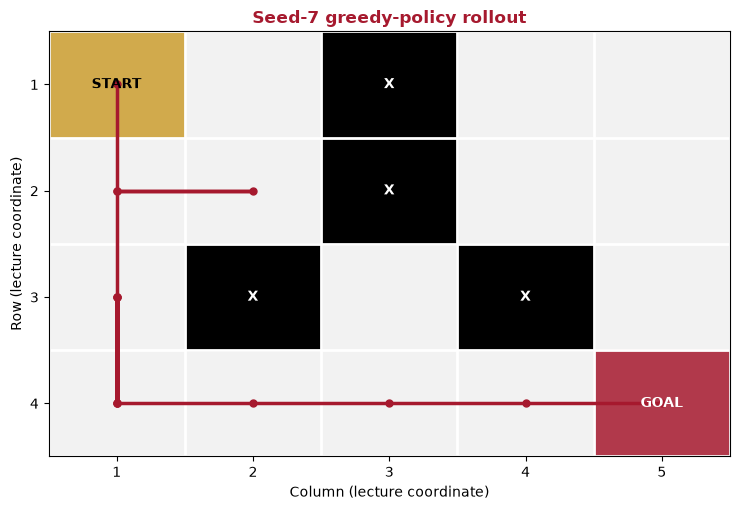

In [21]:
def plot_rollout(trajectory):
    fig = plot_environment()
    ax = fig.axes[0]
    columns = [state[1] for state in trajectory]
    rows = [state[0] for state in trajectory]
    ax.plot(columns, rows, color=SDSU_RED, linewidth=2.5, marker="o", markersize=5)
    ax.set_title("Seed-7 greedy-policy rollout", color=SDSU_RED, weight="bold")
    return fig

rollout_figure = plot_rollout(trajectory)
plt.show()

## Task 6 — Discount-factor experiment (10 points)

For each value in `GAMMA_VALUES`, run value iteration with the unchanged transition and reward model. Store one dictionary per run in `gamma_results` with exactly these keys:

```python
{"gamma": ..., "sweeps": ..., "start_value": ..., "start_action": ...}
```

In [22]:
GAMMA_VALUES = (0.50, 0.80, 0.95, 0.99)
gamma_results = []

for gamma in GAMMA_VALUES:
    V_star, policy_star, deltas = value_iteration(theta=THETA, gamma=gamma, max_iterations=10_000)
    gamma_results.append({"gamma":gamma, "sweeps": len(deltas), "start_value": V_star[START], "start_action": policy_star[START]})
    
for row in gamma_results:
    print(
        f"gamma={row['gamma']:.2f} | sweeps={row['sweeps']:>2d} | "
        f"V(start)={row['start_value']:.6f} | action={row['start_action']}"
    )

gamma=0.50 | sweeps=29 | V(start)=-4.810959 | action=D
gamma=0.80 | sweeps=75 | V(start)=-11.122896 | action=D
gamma=0.95 | sweeps=39 | V(start)=-20.508279 | action=D
gamma=0.99 | sweeps=39 | V(start)=-23.181431 | action=D


In [23]:
# Public checks for Task 6. Do not edit this cell.
EXPECTED_GAMMA_RESULTS = (
    (0.50, 29, -4.810958895944907, "D"),
    (0.80, 75, -11.122895800908449, "D"),
    (0.95, 39, -20.508278595324025, "D"),
    (0.99, 39, -23.18143125514294, "D"),
)

assert len(gamma_results) == len(EXPECTED_GAMMA_RESULTS)
for result, expected in zip(gamma_results, EXPECTED_GAMMA_RESULTS):
    expected_gamma, expected_sweeps, expected_start_value, expected_action = expected
    assert set(result) == {"gamma", "sweeps", "start_value", "start_action"}
    assert math.isclose(result["gamma"], expected_gamma, abs_tol=1e-12)
    assert result["sweeps"] == expected_sweeps
    assert math.isclose(result["start_value"], expected_start_value, abs_tol=1e-6)
    assert result["start_action"] == expected_action

print("Task 6 public checks passed.")

Task 6 public checks passed.


## Submission check

Your notebook is ready to submit when all six messages below appear after **Restart Kernel and Run All**:

- `Task 1 public checks passed.`
- `Task 2 public checks passed.`
- `Task 3 public checks passed.`
- `Task 4 public checks passed.`
- `Task 5 public checks passed.`
- `Task 6 public checks passed.`

No written response is required.